In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
import torch.optim as optim

# Fixed: Added missing __getitem__ method to Dataset class
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # This method was missing - crucial for Dataset class
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # Add your actual data loading logic here
        # For now, this is a placeholder - you need to implement based on your dataframe structure
        img_name = os.path.join(self.root_dir, self.dataframe.iloc[idx, 0])
        image = Image.open(img_name)
        label = self.dataframe.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        return image, label

def prepare_data(root_dir, batch_size=32):
    # Fixed: Moved heavy augmentations to only training data
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Fixed: Using standard ImageNet norms
                           std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(root=os.path.join(root_dir, 'train'), transform=train_transform)
    test_dataset = datasets.ImageFolder(root=os.path.join(root_dir, 'test'), transform=test_transform)

    # Fixed: Added num_workers for faster data loading
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader, train_dataset, test_dataset


In [3]:

class ChestXRayModel_vgg(nn.Module):
    def __init__(self, num_classes):
        super(ChestXRayModel_vgg, self).__init__()

        self.vgg_19 = models.vgg19_bn(pretrained=True)

        # Fixed: Only freeze convolutional layers, allow classifier to train
        for param in self.vgg_19.features.parameters():
            param.requires_grad = False

        num_features = self.vgg_19.classifier[-1].in_features
        self.vgg_19.classifier[-1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.vgg_19(x)

    def train_model(self, train_loader, criterion, optimizer, num_epochs=10, device='cuda'):
        # Fixed: Added device handling and progress tracking
        self.to(device)
        self.train()
        train_losses = []
        train_accuracies = []

        for epoch in range(num_epochs):
            running_loss = 0.0
            correct = 0
            total = 0
            batch_count = 0

            # Fixed: Added progress bar and device transfer
            for batch_idx, (images, labels) in enumerate(train_loader):
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = self(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                batch_count += 1

                # Print progress every 10 batches
                if (batch_idx + 1) % 10 == 0:
                    print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

            epoch_loss = running_loss / total
            epoch_accuracy = 100 * correct / total

            train_losses.append(epoch_loss)
            train_accuracies.append(epoch_accuracy)

            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
            print("-" * 50)

        return train_losses, train_accuracies

    def val_model(self, val_loader, criterion, device='cuda'):
        self.to(device)
        self.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = self(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_loss / total
        val_accuracy = 100 * correct / total
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")
        return val_loss, val_accuracy



In [4]:
# Example usage:
if __name__ == "__main__":
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Prepare data
    train_loader, test_loader, train_dataset, test_dataset = prepare_data('/kaggle/input/chest-xray-pneumonia/chest_xray/', batch_size=32)

    # Create model
    num_classes = len(train_dataset.classes)
    model = ChestXRayModel_vgg(num_classes=num_classes)

    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.vgg_19.classifier.parameters(), lr=0.001)  # Only train classifier

    # Train model
    print("Starting training...")
    train_losses, train_accuracies = model.train_model(
        train_loader, criterion, optimizer, num_epochs=5, device=device
    )

    # Validate model
    print("Starting validation...")
    val_loss, val_accuracy = model.val_model(test_loader, criterion, device=device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:07<00:00, 74.2MB/s]


Starting training...
Epoch [1/5], Batch [10/163], Loss: 0.8559
Epoch [1/5], Batch [20/163], Loss: 0.2869
Epoch [1/5], Batch [30/163], Loss: 0.2688
Epoch [1/5], Batch [40/163], Loss: 0.0399
Epoch [1/5], Batch [50/163], Loss: 0.1852
Epoch [1/5], Batch [60/163], Loss: 0.1162
Epoch [1/5], Batch [70/163], Loss: 0.1016
Epoch [1/5], Batch [80/163], Loss: 0.1310
Epoch [1/5], Batch [90/163], Loss: 0.3432
Epoch [1/5], Batch [100/163], Loss: 0.3373
Epoch [1/5], Batch [110/163], Loss: 0.0847
Epoch [1/5], Batch [120/163], Loss: 0.3257
Epoch [1/5], Batch [130/163], Loss: 0.2386
Epoch [1/5], Batch [140/163], Loss: 0.0324
Epoch [1/5], Batch [150/163], Loss: 0.5360
Epoch [1/5], Batch [160/163], Loss: 0.4792
Epoch 1/5, Loss: 0.3283, Accuracy: 89.19%
--------------------------------------------------
Epoch [2/5], Batch [10/163], Loss: 0.2247
Epoch [2/5], Batch [20/163], Loss: 0.1938
Epoch [2/5], Batch [30/163], Loss: 0.1167
Epoch [2/5], Batch [40/163], Loss: 0.0178
Epoch [2/5], Batch [50/163], Loss: 0.35

In [5]:
# ============================================================
#   EXTRA EVALUATION METRICS (Precision, Recall, F1, CM, ROC)
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

def evaluate_metrics(model, data_loader, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # Predicted class
            _, preds = torch.max(outputs, 1)

            # Probability for ROC (class 1 only)
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # =============================
    # 1. PRECISION - RECALL - F1
    # =============================
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(all_labels, all_preds))

    # =============================
    # 2. CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # =============================
    # 3. ROC CURVE + AUC
    # =============================
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    auc_score = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    print(f"AUC Score: {auc_score:.4f}")


Extra Metrics Evaluation...

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       234
           1       0.93      0.92      0.92       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



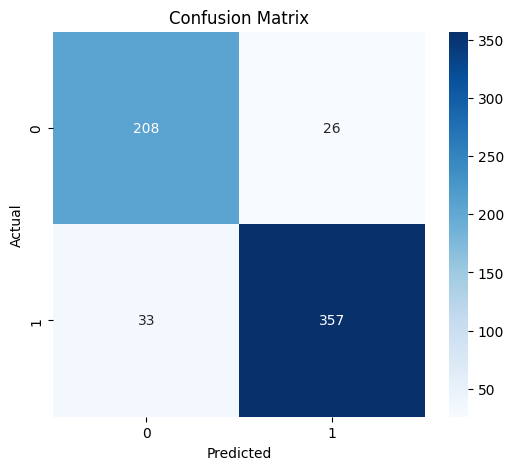

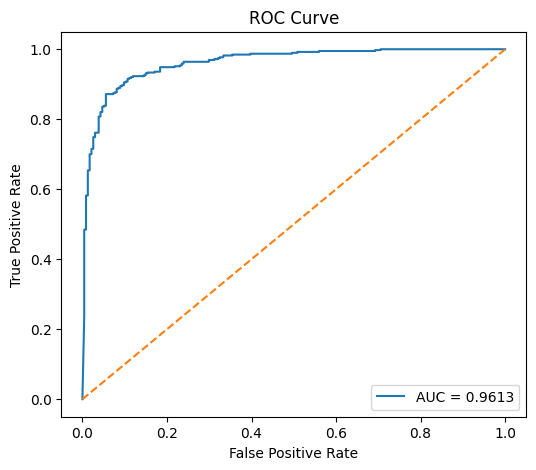

AUC Score: 0.9613


In [6]:
print("Extra Metrics Evaluation...")
evaluate_metrics(model, test_loader, device=device)
